In [54]:
import pandas as pd
df=pd.read_csv('demo.csv')
df.head()

,Date,Speed,Weather,Road_Condition,Vehicle_Type,Time,Seatbelt/Helmet,Severity
0,2025/01/01,45.0,Sunny,Dry,Bike,Day,1.0,Minor
1,2025-01-02,60.0,Rainy,W,Car,Night,0.0,Serious
2,2025-01-03,80.0,Foggy,Wet,Truck,Night,NaN,Fatal
3,2025-01-04,50.0,Sunny,Dry,Car,Day,1.0,Minor
4,2025-01-05,70.0,Rainy,W,Bike,Night,0.0,Serious


In [55]:
#handling missing values
df['Speed'].isna().sum()

np.int64(6)

In [56]:
df['Speed']=df['Speed'].abs()
df['Speed']=df['Speed'].fillna(df['Speed'].mean())

In [57]:
df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])

df['Vehicle_Type'] = df['Vehicle_Type'].fillna(df['Vehicle_Type'].mode()[0])

df['Time'] = df['Time'].fillna(df['Time'].mode()[0])

df['Road_Condition'] = df['Road_Condition'].fillna(df['Road_Condition'].mode()[0])

df['Seatbelt/Helmet']=df['Seatbelt/Helmet'].fillna(df['Seatbelt/Helmet'].mode()[0])

In [58]:
df.head(15)

,Date,Speed,Weather,Road_Condition,Vehicle_Type,Time,Seatbelt/Helmet,Severity
0,2025/01/01,45.000000,Sunny,Dry,Bike,Day,1.0,Minor
1,2025-01-02,60.000000,Rainy,W,Car,Night,0.0,Serious
2,2025-01-03,80.000000,Foggy,Wet,Truck,Night,0.0,Fatal
3,2025-01-04,50.000000,Sunny,Dry,Car,Day,1.0,Minor
4,2025-01-05,70.000000,Rainy,W,Bike,Night,0.0,Serious
5,NaN,90.000000,Foggy,W,Truck,Night,0.0,Fatal
6,2025-01-07,69.613636,Sunny,Dry,Bike,Day,1.0,Minor
7,2025-01-08,65.000000,Sunny,W,Car,Night,0.0,Serious
8,2025-01-09,85.000000,Foggy,W,Truck,Night,0.0,Fatal
9,2025-01-10,40.000000,Sunny,D,Bike,Day,1.0,Minor


In [59]:
#Fix Ambiguity (D/W → Dry/Wet)
df['Road_Condition'] = df['Road_Condition'].replace({ "D":"Dry","W":"Wet"})
df.tail(15)

,Date,Speed,Weather,Road_Condition,Vehicle_Type,Time,Seatbelt/Helmet,Severity
35,2025-02-05,69.613636,Foggy,Wet,Truck,Night,0.0,Fatal
36,2025-02-06,44.000000,Sunny,Dry,Bike,Day,0.0,Minor
37,2025-02-07,66.000000,Rainy,Wet,Bike,Night,0.0,Serious
38,2025/02/08,86.000000,Sunny,Wet,Truck,Night,0.0,Fatal
39,2025-02-09,47.000000,Sunny,Dry,Bike,Day,1.0,Minor
40,2025-02-10,74.000000,Rainy,Wet,Car,Night,0.0,Serious
41,2025/02/11,94.000000,Foggy,Wet,Truck,Night,0.0,Fatal
42,2025-02-12,69.613636,Sunny,Dry,Car,Day,1.0,Minor
43,2025-02-13,77.000000,Rainy,Wet,Bike,Night,0.0,Serious
44,2025-02-14,97.000000,Foggy,Wet,Truck,Night,0.0,Fatal


In [60]:
df['Date'] = pd.to_datetime(df['Date'],format='mixed',dayfirst=True,errors='coerce' )

#Convert to desired format (DD/MM/YYYY)
df['Date'] = df['Date'].dt.strftime("%d/%m/%Y")

df['Date'] = df['Date'].fillna(df['Date'].mode()[0])


In [61]:
df.head()

,Date,Speed,Weather,Road_Condition,Vehicle_Type,Time,Seatbelt/Helmet,Severity
0,01/01/2025,45.0,Sunny,Dry,Bike,Day,1.0,Minor
1,02/01/2025,60.0,Rainy,Wet,Car,Night,0.0,Serious
2,03/01/2025,80.0,Foggy,Wet,Truck,Night,0.0,Fatal
3,04/01/2025,50.0,Sunny,Dry,Car,Day,1.0,Minor
4,05/01/2025,70.0,Rainy,Wet,Bike,Night,0.0,Serious


In [62]:
df.isna().sum()

Date               0
Speed              0
Weather            0
Road_Condition     0
Vehicle_Type       0
Time               0
Seatbelt/Helmet    0
Severity           0
dtype: int64

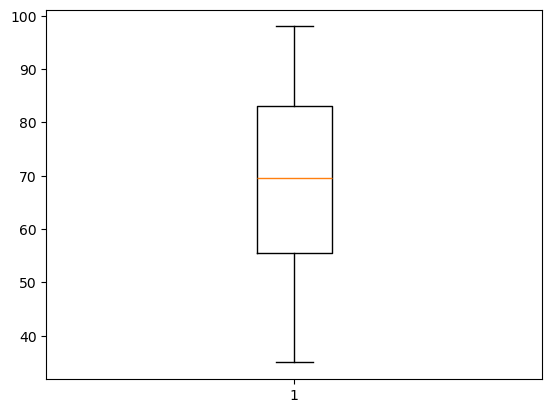

In [63]:
#finding outliers
import matplotlib.pyplot as plt
plt.boxplot(df["Speed"])
plt.show()
Q1 = df["Speed"].quantile(0.25)
Q3 = df["Speed"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [64]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Set custom order
le.fit(['Minor', 'Serious', 'Fatal'])

df['Severity'] = le.transform(df['Severity'])

print(df.head())

         Date  Speed Weather Road_Condition Vehicle_Type   Time  \
0  01/01/2025   45.0   Sunny            Dry         Bike    Day   
1  02/01/2025   60.0   Rainy            Wet          Car  Night   
2  03/01/2025   80.0   Foggy            Wet        Truck  Night   
3  04/01/2025   50.0   Sunny            Dry          Car    Day   
4  05/01/2025   70.0   Rainy            Wet         Bike  Night   

   Seatbelt/Helmet  Severity  
0              1.0         1  
1              0.0         2  
2              0.0         0  
3              1.0         1  
4              0.0         2  


In [66]:
df["Severity"].head(10)

0    1
1    2
2    0
3    1
4    2
5    0
6    1
7    2
8    0
9    1
Name: Severity, dtype: int32

In [67]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Apply on selected columns
df[['Speed', 'Severity']] = scaler.fit_transform(df[['Speed', 'Severity']])

print(df.head())

         Date     Speed Weather Road_Condition Vehicle_Type   Time  \
0  01/01/2025  0.158730   Sunny            Dry         Bike    Day   
1  02/01/2025  0.396825   Rainy            Wet          Car  Night   
2  03/01/2025  0.714286   Foggy            Wet        Truck  Night   
3  04/01/2025  0.238095   Sunny            Dry          Car    Day   
4  05/01/2025  0.555556   Rainy            Wet         Bike  Night   

   Seatbelt/Helmet  Severity  
0              1.0       0.5  
1              0.0       1.0  
2              0.0       0.0  
3              1.0       0.5  
4              0.0       1.0  


In [74]:
import matplotlib.pyplot as plt


In [75]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[['Speed', 'Severity']] = scaler.fit_transform(df[['Speed', 'Severity']])

print(df.head())

         Date     Speed Weather Road_Condition Vehicle_Type   Time  \
0  01/01/2025 -1.454904   Sunny            Dry         Bike    Day   
1  02/01/2025 -0.568259   Rainy            Wet          Car  Night   
2  03/01/2025  0.613935   Foggy            Wet        Truck  Night   
3  04/01/2025 -1.159356   Sunny            Dry          Car    Day   
4  05/01/2025  0.022838   Rainy            Wet         Bike  Night   

   Seatbelt/Helmet  Severity  
0              1.0 -0.024626  
1              0.0  1.206662  
2              0.0 -1.255914  
3              1.0 -0.024626  
4              0.0  1.206662  


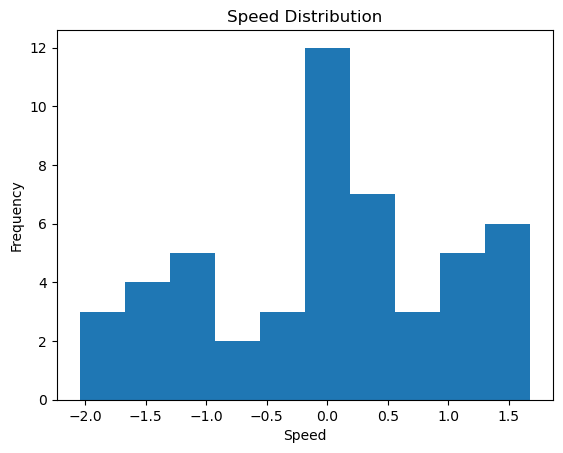

In [76]:
plt.hist(df['Speed'])
plt.title("Speed Distribution")
plt.xlabel("Speed")
plt.ylabel("Frequency")
plt.show()

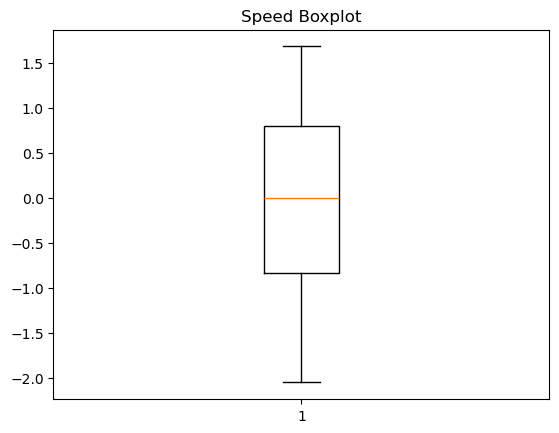

In [77]:
plt.boxplot(x=df['Speed'])
plt.title("Speed Boxplot")
plt.show()

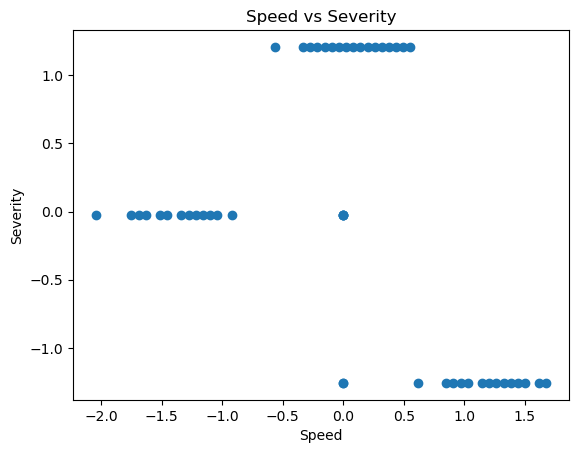

In [78]:
plt.scatter(df['Speed'], df['Severity'])
plt.title("Speed vs Severity")
plt.xlabel("Speed")
plt.ylabel("Severity")
plt.show()

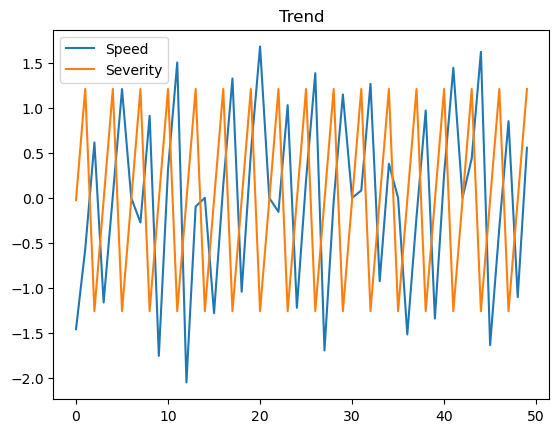

In [79]:
plt.plot(df['Speed'], label='Speed')
plt.plot(df['Severity'], label='Severity')
plt.title("Trend")
plt.legend()
plt.show()